# Problem Statement
Heart disease remains a major public health challenge worldwide. The main goal of this project is to develop a predictive model that can accurately determine whether a person is likely to have heart disease based on medical and lifestyle data. The model aims to assist healthcare professionals in early diagnosis and prevention.


# Import  Labraries

In [240]:
# importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)   # it tells pandas to display all columns of the DataFrame when printing


# Load Data

In [241]:
heart=pd.read_csv(r"C:\Users\padma\OneDrive\Desktop\Python Files\heart_2020_cleaned (1).csv")  

In [242]:
heart

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


# Basic Information About Dataset

In [243]:
heart.shape

(319795, 18)

In [244]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [245]:
heart.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [246]:
heart.describe(include="all")

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,319795,319795.000000,319795,319795,319795,319795.00000,319795.000000,319795,319795,319795,319795,319795,319795,319795,319795.000000,319795,319795,319795
unique,2,NaN,2,2,2,NaN,NaN,2,2,13,6,4,2,5,NaN,2,2,2
top,No,NaN,No,No,No,NaN,NaN,No,Female,65-69,White,No,Yes,Very good,NaN,No,No,No
freq,292422,NaN,187887,298018,307726,NaN,NaN,275385,167805,34151,245212,269653,247957,113858,NaN,276923,308016,289976
mean,NaN,28.325399,NaN,NaN,NaN,3.37171,3.898366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.097075,NaN,NaN,NaN
std,NaN,6.356100,NaN,NaN,NaN,7.95085,7.955235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.436007,NaN,NaN,NaN
min,NaN,12.020000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,24.030000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN
50%,NaN,27.340000,NaN,NaN,NaN,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN
75%,NaN,31.420000,NaN,NaN,NaN,2.00000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN


# Preprocessing

In [247]:
heart.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [248]:
heart.duplicated().sum()

np.int64(18078)

In [249]:
heart.shape

(319795, 18)

In [250]:
heart.drop_duplicates(inplace=True,keep="first")

In [251]:
heart.shape

(301717, 18)

In [252]:
for i in heart.columns:
    print({i:heart[i].unique()})

{'HeartDisease': array(['No', 'Yes'], dtype=object)}
{'BMI': array([16.6 , 20.34, 26.58, ..., 62.42, 51.46, 46.56])}
{'Smoking': array(['Yes', 'No'], dtype=object)}
{'AlcoholDrinking': array(['No', 'Yes'], dtype=object)}
{'Stroke': array(['No', 'Yes'], dtype=object)}
{'PhysicalHealth': array([ 3.,  0., 20., 28.,  6., 15.,  5., 30.,  7.,  1.,  2., 21.,  4.,
       10., 14., 18.,  8., 25., 16., 29., 27., 17., 24., 12., 23., 26.,
       22., 19.,  9., 13., 11.])}
{'MentalHealth': array([30.,  0.,  2.,  5., 15.,  8.,  4.,  3., 10., 14., 20.,  1.,  7.,
       24.,  9., 28., 16., 12.,  6., 25., 17., 18., 21., 29., 22., 13.,
       23., 27., 26., 11., 19.])}
{'DiffWalking': array(['No', 'Yes'], dtype=object)}
{'Sex': array(['Female', 'Male'], dtype=object)}
{'AgeCategory': array(['55-59', '80 or older', '65-69', '75-79', '40-44', '70-74',
       '60-64', '50-54', '45-49', '18-24', '35-39', '30-34', '25-29'],
      dtype=object)}
{'Race': array(['White', 'Black', 'Asian', 'American Indian/Alas

In [253]:
heart.groupby(["AgeCategory","Sex","HeartDisease"]).count()/len(heart)*100


BMI   Smoking  AlcoholDrinking  \
AgeCategory Sex    HeartDisease                                        
18-24       Female No            3.014414  3.014414         3.014414   
                   Yes           0.016572  0.016572         0.016572   
            Male   No            3.570564  3.570564         3.570564   
                   Yes           0.026515  0.026515         0.026515   
25-29       Female No            2.555706  2.555706         2.555706   
                   Yes           0.021875  0.021875         0.021875   
            Male   No            2.806604  2.806604         2.806604   
                   Yes           0.022206  0.022206         0.022206   
30-34       Female No            2.906697  2.906697         2.906697   
                   Yes           0.032812  0.032812         0.032812   
            Male   No            2.968676  2.968676         2.968676   
                   Yes           0.042092  0.042092         0.042092   
35-39       Female No            3.296135  3.296135         3.296135   
                   Yes           0.049053  0.049053         0.049053   
            Male   No            3.077387  3.077387         3.077387   
                   Yes           0.049053  0.049053         0.049053   
40-44       Female No            3.394240  3.394240         3.394240   
                   Yes           0.080539  0.080539         0.080539   
            Male   No            3.019386  3.019386         3.019386   
                   Yes           0.080539  0.080539         0.080539   
45-49       Female No            3.510243  3.510243         3.510243   
                   Yes           0.106060  0.106060         0.106060   
            Male   No            3.043912  3.043912         3.043912   
                   Yes           0.140198  0.140198         0.140198   
50-54       Female No            4.000437  4.000437         4.000437   
                   Yes           0.197536  0.197536         0.197536   
            Male   No            3.408161  3.408161         3.408161   
                   Yes           0.260840  0.260840         0.260840   
55-59       Female No            4.530073  4.530073         4.530073   
                   Yes           0.300944  0.300944         0.300944   
            Male   No            3.892058  3.892058         3.892058   
                   Yes           0.427884  0.427884         0.427884   
60-64       Female No            5.027559  5.027559         5.027559   
                   Yes           0.416284  0.416284         0.416284   
            Male   No            4.218854  4.218854         4.218854   
                   Yes           0.684416  0.684416         0.684416   
65-69       Female No            5.087549  5.087549         5.087549   
                   Yes           0.485886  0.485886         0.485886   
            Male   No            4.058770  4.058770         4.058770   
                   Yes           0.864386  0.864386         0.864386   
70-74       Female No            4.735563  4.735563         4.735563   
                   Yes           0.598243  0.598243         0.598243   
            Male   No            3.370045  3.370045         3.370045   
                   Yes           0.998286  0.998286         0.998286   
75-79       Female No            3.331267  3.331267         3.331267   
                   Yes           0.543556  0.543556         0.543556   
            Male   No            2.199081  2.199081         2.199081   
                   Yes           0.791139  0.791139         0.791139   
80 or older Female No            3.814502  3.814502         3.814502   
                   Yes           0.867038  0.867038         0.867038   
            Male   No            2.126827  2.126827         2.126827   
                   Yes           0.931336  0.931336         0.931336   

                                   Stroke  PhysicalHealth  MentalHealth  \
AgeCategory Sex    HeartDisease                                           

In [254]:
heart["Diabetic"].value_counts()

Diabetic
No                         251796
Yes                         40589
No, borderline diabetes      6776
Yes (during pregnancy)       2556
Name: count, dtype: int64

In [255]:
heart["SleepTime"].value_counts()

SleepTime
8.0     90202
7.0     89445
6.0     64655
5.0     19101
9.0     15853
10.0     7782
4.0      7730
12.0     2204
3.0      1992
2.0       788
1.0       551
11.0      415
14.0      243
16.0      236
15.0      189
18.0      102
13.0       97
20.0       64
24.0       30
17.0       21
22.0        9
19.0        3
23.0        3
21.0        2
Name: count, dtype: int64

In [256]:
heart["Sex"].value_counts()

Sex
Female    159671
Male      142046
Name: count, dtype: int64

In [257]:
pd.crosstab(heart['Smoking'], heart['HeartDisease']) / len(heart)*100

HeartDisease,No,Yes
Smoking,,
No,54.033415,3.739928
Yes,36.931297,5.295360


# Visualization

In [258]:
import seaborn as sns

In [259]:
heart["HeartDisease"].value_counts()

HeartDisease
No     274456
Yes     27261
Name: count, dtype: int64

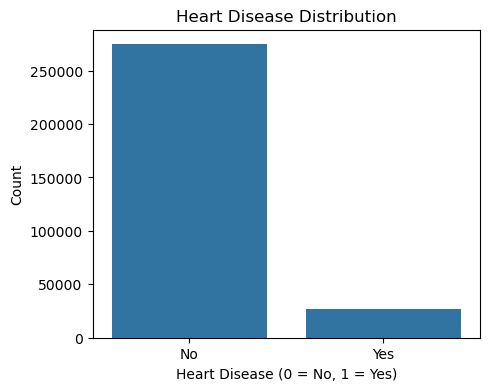

In [260]:
# Shows how many people have heart disease vs not (your target variable).

plt.figure(figsize=(5,4))
sns.countplot(data=heart,x=heart["HeartDisease"]);
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# It explains your main target variable and checks whether data is balanced or not.

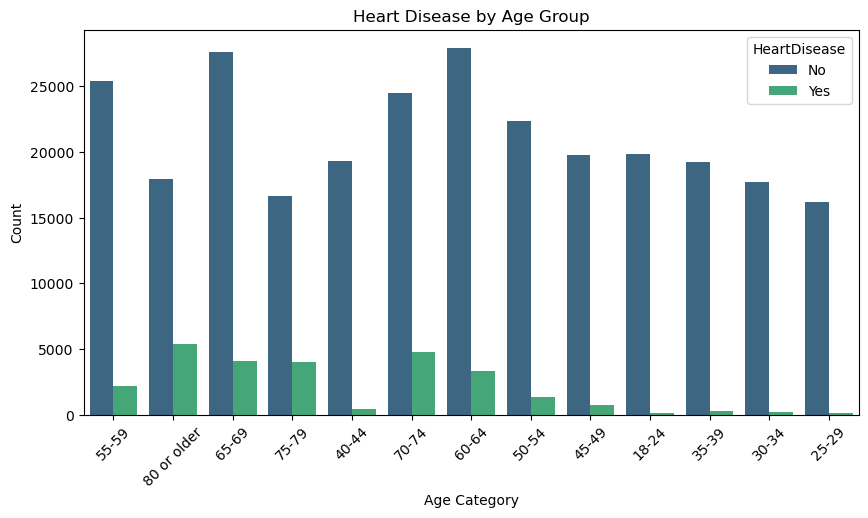

In [261]:
# Shows how heart disease increases with age.

plt.figure(figsize=(10,5))
sns.countplot(x='AgeCategory', hue='HeartDisease', data=heart, palette='viridis')
plt.title("Heart Disease by Age Group")
plt.xlabel("Age Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# This is a key health insight — shows that older age groups have higher heart disease risk.

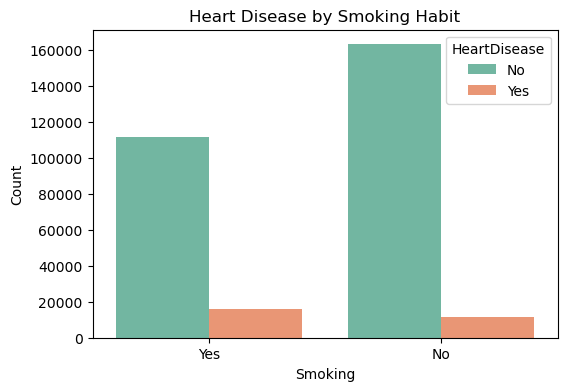

In [262]:
# Compares smokers vs non-smokers in relation to heart disease.

plt.figure(figsize=(6,4))
sns.countplot(x='Smoking', hue='HeartDisease', data=heart, palette='Set2')
plt.title("Heart Disease by Smoking Habit")
plt.xlabel("Smoking")
plt.ylabel("Count")
plt.show()


# Smoking is a major heart disease risk factor, this supports your model’s findings.

In [263]:
# calculate the percentage

heart.groupby(["AgeCategory","HeartDisease"])["SleepTime"].count()/len(heart)*100

# This means we are creating subgroups for each department and whether employees quit or not

AgeCategory  HeartDisease
18-24        No              6.584979
             Yes             0.043087
25-29        No              5.362310
             Yes             0.044081
30-34        No              5.875373
             Yes             0.074905
35-39        No              6.373522
             Yes             0.098105
40-44        No              6.413626
             Yes             0.161078
45-49        No              6.554155
             Yes             0.246257
50-54        No              7.408598
             Yes             0.458377
55-59        No              8.422131
             Yes             0.728829
60-64        No              9.246413
             Yes             1.100700
65-69        No              9.146319
             Yes             1.350272
70-74        No              8.105609
             Yes             1.596529
75-79        No              5.530348
             Yes             1.334694
80 or older  No              5.941329
             Yes        

# Encoding
Convert Categorical Columns to Numbers

In [264]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in heart.columns:
    if heart[col].dtype == 'object':
        heart[col] = encoder.fit_transform(heart[col])

In [265]:
heart.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,5,2,1,4,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,5,0,1,4,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,5,2,1,1,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,5,0,0,2,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,5,0,1,4,8.0,0,0,0


# Split Data into Input (X) and Target (y)

In [266]:
# Split into Features and Target
# X = input features, y = target column
x = heart.drop("HeartDisease", axis=1)
y = heart["HeartDisease"]

print("\n Data Split Done!")
print("Shape of X:", x.shape)
print("Shape of y:", y.shape)


 Data Split Done!
Shape of X: (301717, 17)
Shape of y: (301717,)


# Split Data into Training and Testing

In [267]:

from sklearn.model_selection import train_test_split

# Split data: 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("\n Training and Testing Data Split Done!")
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)


 Training and Testing Data Split Done!
Training Data Shape: (241373, 17)
Testing Data Shape: (60344, 17)


# Create and Train the Decision Tree Model

In [268]:
# Create and Train the Decision Tree Model
# Create Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_DecisionTree = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Train the model
model_DecisionTree.fit(x_train, y_train)

print("\n Model Trained Successfully!")


 Model Trained Successfully!


# Make Prediction

In [269]:
# Make Predictions
# Predict on test data
y_pred = model_DecisionTree.predict(x_test)

print("\n Predictions Completed!")
print("Sample Predictions:", y_pred[:10])


 Predictions Completed!
Sample Predictions: [0 0 0 0 0 0 0 0 0 0]


# Check Model Accuracy and Results

In [270]:
# Evaluate the Model
# Accuracy score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(" Accuracy of the model:", round(acc, 4))


Confusion Matrix:
 [[54631   263]
 [ 5209   241]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95     54894
           1       0.48      0.04      0.08      5450

    accuracy                           0.91     60344
   macro avg       0.70      0.52      0.52     60344
weighted avg       0.87      0.91      0.87     60344


--- Model Evaluation ---
 Accuracy of the model: 0.9093


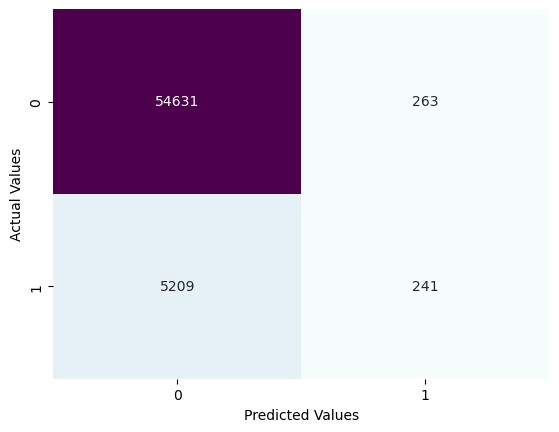

Classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     54894
           1       0.48      0.04      0.08      5450

    accuracy                           0.91     60344
   macro avg       0.70      0.52      0.52     60344
weighted avg       0.87      0.91      0.87     60344

Accuracy of the model: 0.9093198992443325


In [271]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cfm = confusion_matrix(y_test, y_pred)

sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print('Classification report:')
print(classification_report(y_test,y_pred))

acc = accuracy_score(y_test, y_pred)
print("Accuracy of the model:", acc)

In [272]:
model_DecisionTree.score(x_train,y_train)

0.9104580876900068

# Show Feature Importance

In [273]:
# display the importance of each feature used by the Decision Tree Model
# model_DecisionTree.feature_importances_ -> the importance score of the feature

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance ---")
print(feature_importance.head(10))


--- Feature Importance ---
           Feature  Importance
8      AgeCategory    0.536771
6      DiffWalking    0.181505
3           Stroke    0.101189
7              Sex    0.089369
12       GenHealth    0.050950
15   KidneyDisease    0.018373
4   PhysicalHealth    0.012153
10        Diabetic    0.007103
1          Smoking    0.001717
13       SleepTime    0.000871


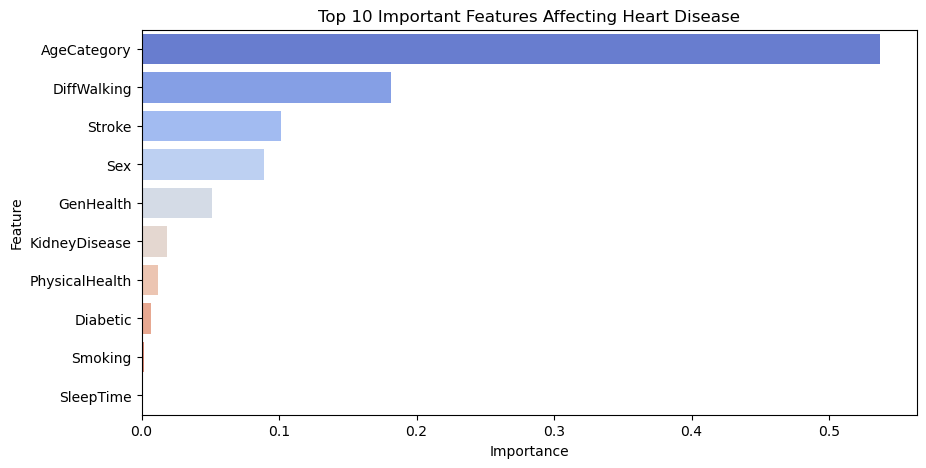

In [274]:
# Shows which features were most important in prediction.

importances = model_DecisionTree.feature_importances_
features = x.columns
feat_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_importance.head(10), palette='coolwarm')
plt.title("Top 10 Important Features Affecting Heart Disease")
plt.show()


# It connects your machine learning part with your data analysis — showing what matters most.

# Visualize the Decision Tree

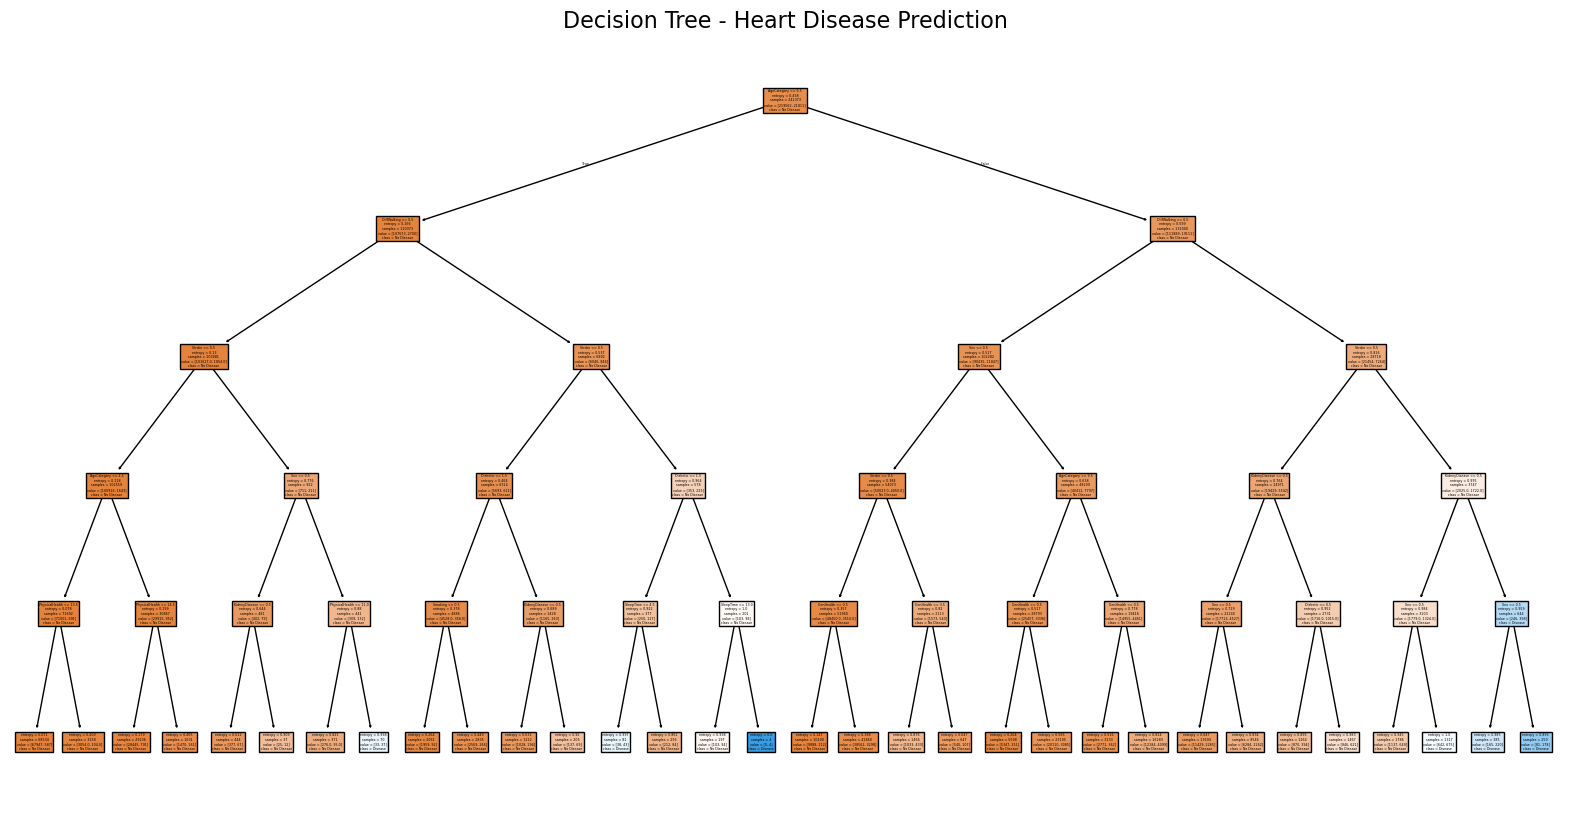

In [275]:
# Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(model_DecisionTree, filled=True, feature_names=x.columns, class_names=['No Disease','Disease'])
plt.title("Decision Tree - Heart Disease Prediction", fontsize=16)
plt.show()


# Conclusion
This project successfully developed a Decision Tree model for predicting heart disease with an accuracy of 90.93%. The model demonstrates that factors such as BMI, age, smoking, and physical activity play key roles in determining heart health. For future improvement, advanced algorithms like Random Forest and Gradient Boosting can be applied to improve precision and recall.
